In [331]:
# Set some global parameters and paths
import os
import csv
import re
import matplotlib.pyplot as plt
import numpy as np
from math import log
from itertools import product

DEBUG = False
RELOAD = False
BASE_DIR = os.path.abspath("")
ROOT_DIR = os.path.abspath(os.path.join(BASE_DIR, '../../'))
EXPERIMENTS_DIR = os.path.join(BASE_DIR, 'experiments')
RESULT_DIR = os.path.join(ROOT_DIR, 'results/lumi_mixer/cases')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')

if DEBUG:
    print("Base Directory:", BASE_DIR)
    print("Root Directory:", ROOT_DIR)
    print("Experiments Directory:", EXPERIMENTS_DIR)
    print("Data Directory:", RESULT_DIR)
    print("Output Directory:", OUTPUT_DIR)

# Open an experiment, read the information there

Each experiment is a CSV file with headers reflecting the parameters used to
create the case files.

In [332]:
def read_experiment_file(experiment_name) -> list:
    """
    Read the experiment file and return a list of experiments with their
    parameters.

    Args:
        file_path (str): Path to the experiment CSV file.
    Returns:
        list: List of dictionaries, each representing an experiment with its
        parameters.
    """
    file_path = os.path.join(EXPERIMENTS_DIR, experiment_name)

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Experiment file not found: {file_path}")

    # Read the CSV file and parse its contents
    with open(os.path.join(file_path), 'r') as file:
        reader = csv.DictReader(file, delimiter=',', skipinitialspace=True)
        tmp = [row for row in reader]

    # Extract experiments and convert types
    experiments = []
    for row in tmp:
        experiment = {}
        for key, value in row.items():
            try:
                experiment[key] = int(value)
            except ValueError:
                try:
                    experiment[key] = float(value)
                except ValueError:
                    if value.lower() in ['true', 'false']:
                        experiment[key] = value.lower() == 'true'
                    else:
                        experiment[key] = value

        # Check if the experiment has been completed and set the status
        log_file = f"{experiment['case_name']}.log"
        experiment['log_file'] = os.path.join(RESULT_DIR,
                                              experiment['case_name'],
                                              log_file)
        if os.path.exists(experiment['log_file']):
            experiment['status'] = 'done'
        else:
            experiment['status'] = 'pending'

        experiments.append(experiment)

    return experiments


In [333]:
if DEBUG:
    experiment_file = os.path.join(EXPERIMENTS_DIR, 'single_node_capacity.csv')
    experiment = read_experiment_file(experiment_file)
    print(f"Loaded {len(experiment)} experiments.")
    for exp in experiment:
        print(exp)


# Parse the log files to extract the performance metrics

In [334]:
def read_rt_stats_from_log(experiment: dict) -> list:
    """
    Read the runtime statistics from the log file.
    The runtime statistics will be stored in the experiment dictionary
    under the key 'runtimes'.

    Args:
        log_path (str): Path to the log file.
    """

    if not os.path.exists(experiment['log_file']):
        raise FileNotFoundError(
            f"Log file not found: {experiment['log_file']}")

    with open(experiment['log_file'], 'r') as file:
        lines = file.readlines()

    # Look for the pattern
    # `------Runtime statistics------` followed by an empty line
    # Then read the following table until an empty line is found

    start_index = None
    for i, line in enumerate(lines):
        if '------Runtime statistics------' in line:
            start_index = i + 2  # Skip the next empty line
            break
    if start_index is None:
        raise ValueError(
            f"Runtime statistics section not found in log file:\n\t{experiment['log_file']}"
        )

    end_index = start_index
    while end_index < len(lines) and lines[end_index].strip():
        end_index += 1

    # Extract the relevant lines
    stats_lines = lines[start_index:end_index]

    # Parse the statistics lines into a structured format
    header = ["Region name", "Total time", "Avg time", "Range +/-"]

    data = {}
    for line in stats_lines[2:]:
        parts = line.strip().split()
        if len(parts) >= 4:
            region_name = " ".join(parts[:-3])
            total_time = float(parts[-3])
            avg_time = float(parts[-2])
            range_plus_minus = float(parts[-1])

            data[region_name] = {
                header[1]: total_time,
                header[2]: avg_time,
                header[3]: range_plus_minus
            }
    experiment['runtimes'] = data

    # Read the time to solution from the output log file
    output_file = os.path.join(RESULT_DIR, experiment['case_name'],
                               'output.log')
    with open(output_file, 'r') as file:
        output_lines = file.readlines()
    pattern = re.compile(r'Execution time: \d\d:\d\d:\d\d')
    for line in output_lines:
        match = pattern.search(line)
        if match:
            time_str = match.group().split(': ')[1]
            h, m, s = map(int, time_str.split(':'))
            experiment['time_to_solution'] = h * 3600 + m * 60 + s
            break
    if 'time_to_solution' not in experiment:
        raise ValueError(
            f"Time to solution not found in output log file:\n\t{output_file}")


In [335]:
# Parse the log files to extract the performance metrics
if DEBUG:
    read_rt_stats_from_log(experiment[1])
    print("Parsed Statistics Data:")
    for region, times in experiment[1]['runtimes'].items():
        print(f"Region: '{region}'")
        for key, value in times.items():
            print(f"   '{key}': {value}")


In [336]:
def extract_times(experiment: list,
                  region: str,
                  measure: str = 'Avg time') -> np.ndarray:
    """
    Extract specific timing data from the experiment's runtimes.

    Args:
        experiment (list): The experiment dictionary containing runtimes.
        region (str): The region name to extract.
        measure (str): The measure to extract (default is 'Avg Time').
                       Possible values:  'Total time' 'Avg. time' 'Range +/-'

    Returns:
        np.ndarray: Array of extracted times.
    """

    result = np.array([])
    for exp in experiment:
        if exp['status'] != 'done':
            continue

        if 'runtimes' not in exp:
            read_rt_stats_from_log(exp)

        if region in exp['runtimes']:
            result = np.append(result, exp['runtimes'][region][measure])
        else:
            raise ValueError('Region not found in experiment')

    return result

# Single node capacity analysis

Here we have investigated the effect of adding more elements onto a single node
of LUMi. This will help us choose the right mesh size for a given problem.

In [337]:
single_node_capacity = read_experiment_file('single_node_capacity.csv')

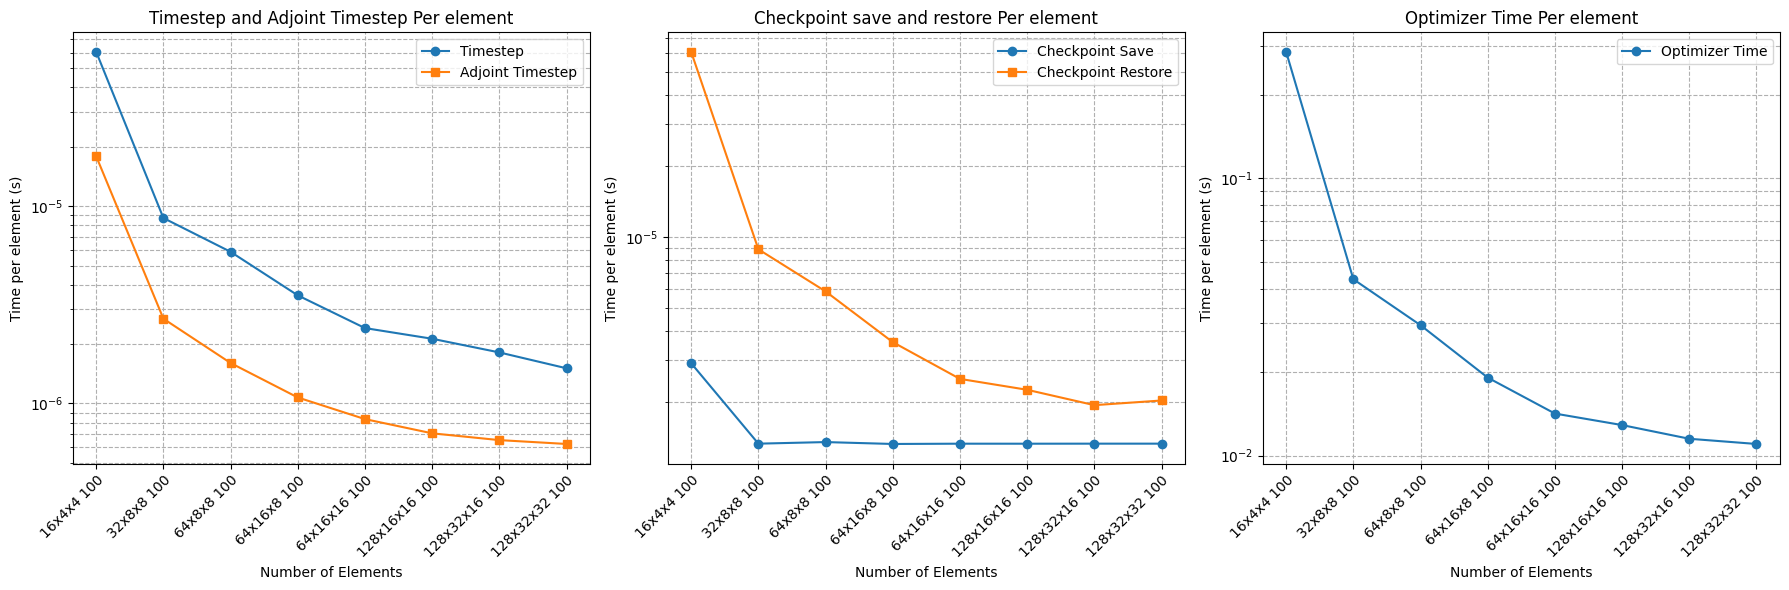

In [338]:
# Plot the timestep and adjoint timestep as a function of the number of elements
num_elements = np.array([])
timestep = np.array([])
adjoint_timestep = np.array([])
checkpoint_save = np.array([])
checkpoint_restore = np.array([])
optimizer_time = np.array([])

num_elements = np.array([
    exp['Nx'] * exp['Ny'] * exp['Nz'] for exp in single_node_capacity
    if exp['status'] == 'done'
])
num_checkpoints = np.array([
    exp['N_memory'] for exp in single_node_capacity if exp['status'] == 'done'
])
mesh_labels = np.array([
    f"{exp['Nx']}x{exp['Ny']}x{exp['Nz']} {exp['N_memory']}"
    for exp in single_node_capacity
])

timestep = extract_times(single_node_capacity, 'Time-Step')
adjoint_timestep = extract_times(single_node_capacity, 'Time-Step Adjoint')
checkpoint_save = extract_times(single_node_capacity, 'Checkpoint save')
checkpoint_restore = extract_times(single_node_capacity, 'Checkpoint restore')
optimizer_time = extract_times(single_node_capacity, 'Optimizer iteration',
                               'Total time')

# Sort the data by the x_axis
# sorted_indices = np.argsort(timestep / num_elements, stable=True)
# mesh_labels = mesh_labels[sorted_indices]
# timestep = timestep[sorted_indices]
# adjoint_timestep = adjoint_timestep[sorted_indices]
# checkpoint_save = checkpoint_save[sorted_indices]
# checkpoint_restore = checkpoint_restore[sorted_indices]
# optimizer_time = optimizer_time[sorted_indices]

[fig_single, ax_single] = plt.subplots(1, 3, figsize=(18, 6))
ax_single[0].set_title('Timestep and Adjoint Timestep Per element')
ax_single[0].plot(timestep / num_elements, marker='o', label='Timestep')
ax_single[0].plot(adjoint_timestep / num_elements,
                  marker='s',
                  label='Adjoint Timestep')

ax_single[1].set_title('Checkpoint save and restore Per element')
ax_single[1].plot(checkpoint_save / num_elements,
                  marker='o',
                  label='Checkpoint Save')
ax_single[1].plot(checkpoint_restore / num_elements,
                  marker='s',
                  label='Checkpoint Restore')

ax_single[2].set_title('Optimizer Time Per element')
ax_single[2].plot(optimizer_time / num_elements,
                  marker='o',
                  label='Optimizer Time')

#  Set xscale to be log2 and yscale to be log10
for ax in ax_single:
    ax.set_yscale('log', base=10)
    ax.set_xlabel('Number of Elements')
    ax.set_ylabel('Time per element (s)')
    ax.set_xticks(range(len(mesh_labels)))
    ax.set_xticklabels(mesh_labels,
                       rotation=45,
                       ha='right',
                       rotation_mode='anchor')
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

# Checkpoints

We know a limiting factor is the checkpoints. This section will investigate the
behaviour as we use more checkpoints for a couple of mesh sizes.

In [339]:
checkpoint_count = read_experiment_file('memory_checkpoints.csv')

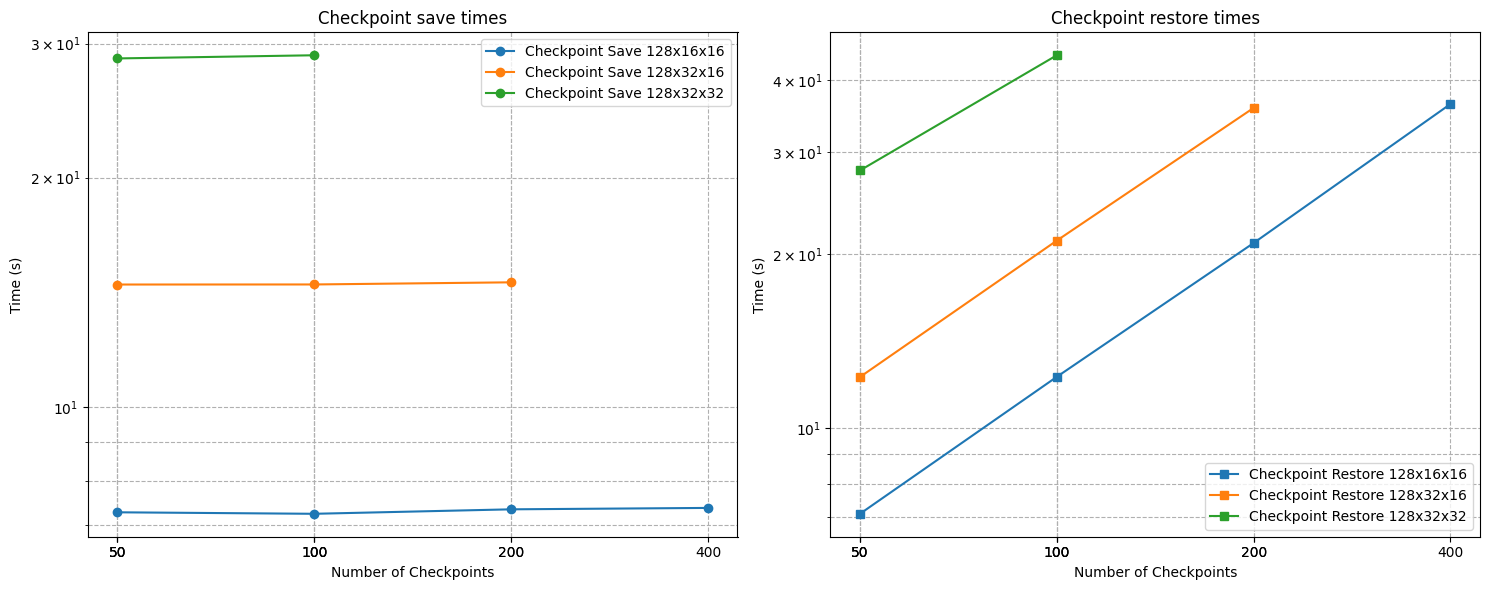

In [340]:
# Plot the checkpoint save and restore times as a function of the number of
# checkpoints.

num_memory = np.array(
    [exp['N_memory'] for exp in checkpoint_count if exp['status'] == 'done'])
checkpoint_save = extract_times(checkpoint_count, 'Checkpoint save',
                                'Total time')
checkpoint_restore = extract_times(checkpoint_count, 'Checkpoint restore',
                                   'Total time')

tsteps = 1e-1 / 1e-4
nc = np.array(tsteps // num_memory, dtype=float) + 2

checkpoint_save = checkpoint_save / nc
checkpoint_restore = checkpoint_restore / nc

# Get the mesh size for the labels and group by mesh size
mesh_size = np.array([
    f"{exp['Nx']}x{exp['Ny']}x{exp['Nz']}" for exp in checkpoint_count
    if exp['status'] == 'done'
])
mesh_labels = np.unique(mesh_size)

# Plot the checkpoint save and restore times in two subfigures grouped by
# mesh size
[fig_checkpoint, ax_checkpoint] = plt.subplots(1, 2, figsize=(15, 6))

for mesh in mesh_labels:
    mask = mesh_size == mesh
    ax_checkpoint[0].plot(num_memory[mask],
                          checkpoint_save[mask],
                          marker='o',
                          label=f'Checkpoint Save {mesh}')
    ax_checkpoint[1].plot(num_memory[mask],
                          checkpoint_restore[mask],
                          marker='s',
                          label=f'Checkpoint Restore {mesh}')

for i, ax in enumerate(ax_checkpoint):
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=10)
    ax.set_xlabel('Number of Checkpoints')
    ax.set_ylabel('Time (s)')
    ax.set_xticks(num_memory)
    ax.set_xticklabels(num_memory)
    if i == 0:
        ax.set_title('Checkpoint save times')
    else:
        ax.set_title('Checkpoint restore times')
    ax.legend()
    ax.grid(True, which="both", ls="--")

plt.tight_layout()

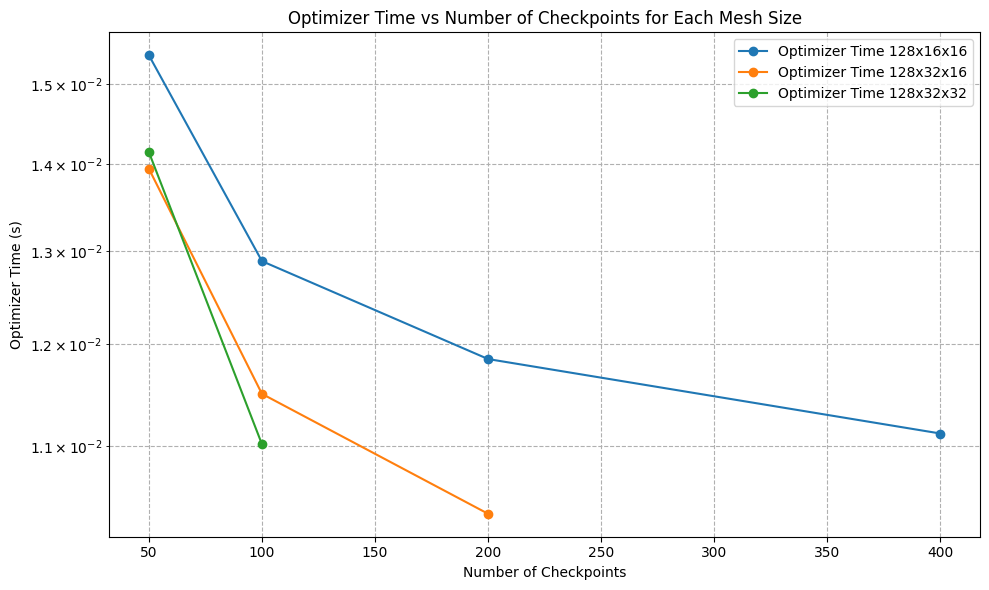

In [341]:
checkpoint_optimizer_time = extract_times(checkpoint_count,
                                          'Optimizer iteration', 'Total time')
checkpoint_num_elements = np.array([
    exp['Nx'] * exp['Ny'] * exp['Nz'] for exp in checkpoint_count
    if exp['status'] == 'done'
])

plt.figure(figsize=(10, 6))

for mesh in mesh_labels:
    mask = mesh_size == mesh
    plt.plot(num_memory[mask],
             checkpoint_optimizer_time[mask] / checkpoint_num_elements[mask],
             marker='o',
             label=f'Optimizer Time {mesh}')

plt.yscale('log', base=10)
plt.xlabel('Number of Checkpoints')
plt.ylabel('Optimizer Time (s)')
plt.title('Optimizer Time vs Number of Checkpoints for Each Mesh Size')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

# Initial Weak scaling

From the above it seems the 128x16x16 with 400 checkpoints is a good candidate
for a weak scaling study. To narrow down the mesh size we can do a weak scaling
study with a few different aspect ratios and checkpoint amounts to see how they
behave as the network is stressed.


In [342]:
weak_400 = read_experiment_file('weak_scaling_400.csv')
weak_200 = read_experiment_file('weak_scaling_200.csv')
weak_100 = read_experiment_file('weak_scaling_100.csv')

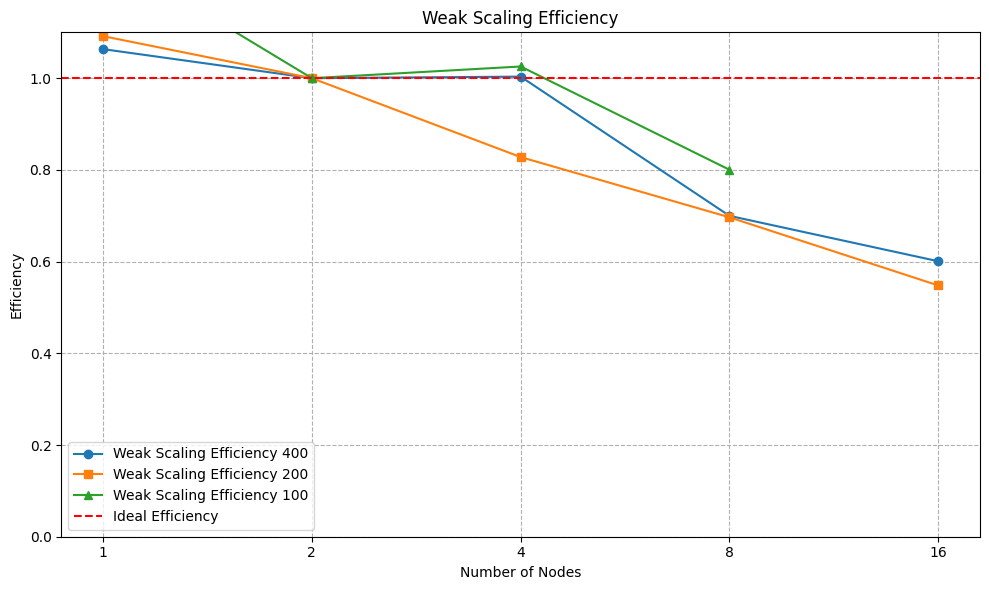

In [343]:
weak_400_nodes = np.array(
    [exp['nodes'] for exp in weak_400 if exp['status'] == 'done'])
weak_200_nodes = np.array(
    [exp['nodes'] for exp in weak_200 if exp['status'] == 'done'])
weak_100_nodes = np.array(
    [exp['nodes'] for exp in weak_100 if exp['status'] == 'done'])

weak_400_times = extract_times(weak_400, 'Optimizer iteration', 'Total time')
weak_200_times = extract_times(weak_200, 'Optimizer iteration', 'Total time')
weak_100_times = extract_times(weak_100, 'Optimizer iteration', 'Total time')

# Merge the node lists to make sure you have all
x_axis = np.unique(
    np.concatenate((weak_400_nodes, weak_200_nodes, weak_100_nodes)))

# Sort the nodes and times by nodes
sorted_indices_400 = np.argsort(weak_400_nodes, stable=True)
weak_400_nodes = weak_400_nodes[sorted_indices_400]
weak_400_times = weak_400_times[sorted_indices_400]

sorted_indices_200 = np.argsort(weak_200_nodes, stable=True)
weak_200_nodes = weak_200_nodes[sorted_indices_200]
weak_200_times = weak_200_times[sorted_indices_200]

sorted_indices_100 = np.argsort(weak_100_nodes, stable=True)
weak_100_nodes = weak_100_nodes[sorted_indices_100]
weak_100_times = weak_100_times[sorted_indices_100]

plt.figure(figsize=(10, 6))
plt.plot(weak_400_nodes,
         weak_400_times[1] / weak_400_times,
         marker='o',
         label='Weak Scaling Efficiency 400')
plt.plot(weak_200_nodes,
         weak_200_times[1] / weak_200_times,
         marker='s',
         label='Weak Scaling Efficiency 200')
plt.plot(weak_100_nodes,
         weak_100_times[1] / weak_100_times,
         marker='^',
         label='Weak Scaling Efficiency 100')

plt.xscale('log', base=2)
plt.xlabel('Number of Nodes')
plt.ylabel('Efficiency')
plt.xticks(x_axis, x_axis)
plt.title('Weak Scaling Efficiency')
plt.ylim(0, 1.1)
plt.axhline(y=1.0, color='r', linestyle='--', label='Ideal Efficiency')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

# The actual weak scaling study

We have determined so far that a mesh size of 64x16x16 with 800 checkpoints is
the best candidate for a weak scaling study. 
However, we have not enabled the parallel filesystem. For now we go with this
and tune the file system striping to this case.

- Stripe count: 1, stripe size: 1MB - falls bellow 60% at 8 nodes.
- 

In [344]:
weak_scaling_experiments = read_experiment_file('weak_scaling.csv')

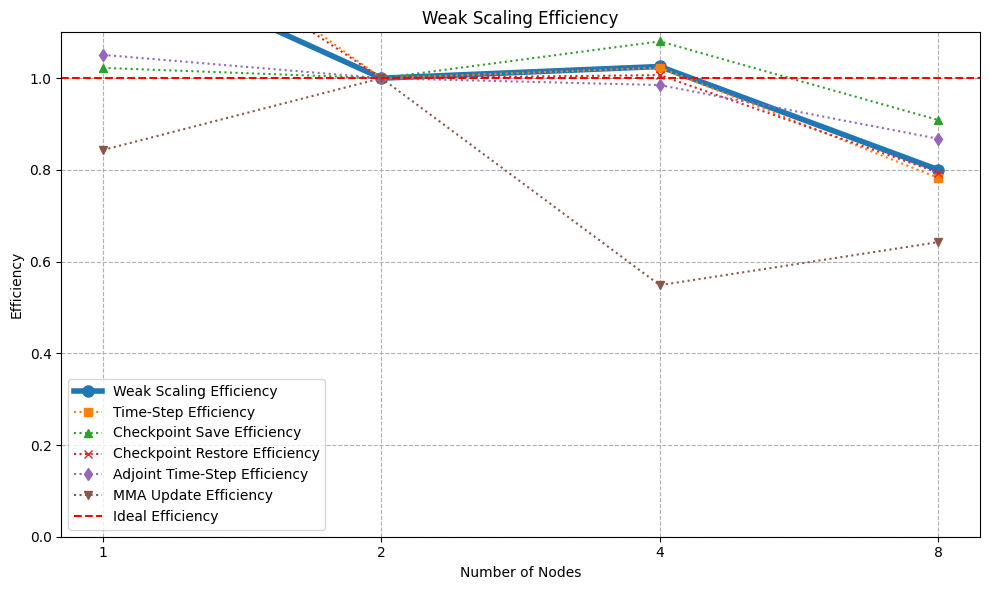

In [345]:
weak_scaling_nodes = np.array([
    exp['nodes'] for exp in weak_scaling_experiments if exp['status'] == 'done'
])
weak_scaling_times = extract_times(weak_scaling_experiments,
                                   'Optimizer iteration', 'Total time')
weak_scaling_time_step = extract_times(weak_scaling_experiments, 'Time-Step')
weak_scaling_time_step_adj = extract_times(weak_scaling_experiments,
                                           'Time-Step Adjoint')
weak_scaling_checkpoint_save = extract_times(weak_scaling_experiments,
                                             'Checkpoint save')
weak_scaling_checkpoint_restore = extract_times(weak_scaling_experiments,
                                                'Checkpoint restore')
weak_scaling_mma_time = extract_times(weak_scaling_experiments,
                                      'MMA KKT computation', 'Total time')

# Sort the nodes and times by nodes
sorted_indices = np.argsort(weak_scaling_nodes)
weak_scaling_nodes = weak_scaling_nodes[sorted_indices]
weak_scaling_times = weak_scaling_times[sorted_indices]
weak_scaling_time_step = weak_scaling_time_step[sorted_indices]

plt.figure(figsize=(10, 6))

plt.plot(weak_scaling_nodes,
         weak_scaling_times[1] / weak_scaling_times,
         marker='o',
         markersize=8,
         linewidth=4,
         label='Weak Scaling Efficiency')
plt.plot(weak_scaling_nodes,
         weak_scaling_time_step[1] / weak_scaling_time_step,
         marker='s',
         linestyle=':',
         label='Time-Step Efficiency')
plt.plot(weak_scaling_nodes,
         weak_scaling_checkpoint_save[1] / weak_scaling_checkpoint_save,
         marker='^',
         linestyle=':',
         label='Checkpoint Save Efficiency')
plt.plot(weak_scaling_nodes,
         weak_scaling_checkpoint_restore[1] / weak_scaling_checkpoint_restore,
         marker='x',
         linestyle=':',
         label='Checkpoint Restore Efficiency')
plt.plot(weak_scaling_nodes,
         weak_scaling_time_step_adj[1] / weak_scaling_time_step_adj,
         marker='d',
         linestyle=':',
         label='Adjoint Time-Step Efficiency')
plt.plot(weak_scaling_nodes,
         weak_scaling_mma_time[1] / weak_scaling_mma_time,
         marker='v',
         linestyle=':',
         label='MMA Update Efficiency')

plt.xscale('log', base=2)
plt.xlabel('Number of Nodes')
plt.ylabel('Efficiency')
plt.xticks(weak_scaling_nodes, weak_scaling_nodes)
plt.title('Weak Scaling Efficiency')
plt.ylim(0, 1.1)
plt.axhline(y=1.0, color='r', linestyle='--', label='Ideal Efficiency')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

In [346]:
# Combine all experiment lists into one unique list keyed by case_name
_sources = [
    read_experiment_file('single_node_capacity.csv'),
    read_experiment_file('memory_checkpoints.csv'),
    read_experiment_file('weak_scaling_400.csv'),
    read_experiment_file('weak_scaling_200.csv'),
    read_experiment_file('weak_scaling_100.csv'),
    read_experiment_file('weak_scaling.csv'),
    read_experiment_file('storage_test.csv'),
    read_experiment_file('run_time_test.csv')
]

_combined = {}
for lst in _sources:
    for exp in lst:
        key = exp.get('case_name') or f"_anon_{id(exp)}"
        if key not in _combined:
            _combined[key] = exp

all_experiments = sorted(_combined.values(), key=lambda e: e.get('case_name'))
all_experiments = [exp for exp in all_experiments if exp['status'] == 'done']

all_elements = np.array(
    [exp['Nx'] * exp['Ny'] * exp['Nz'] for exp in all_experiments])
all_nodes = np.array([exp['nodes'] for exp in all_experiments])
all_memory = np.array([exp['N_memory'] for exp in all_experiments])

# Trim away all experiments with 1 node
mask = all_nodes > 1
all_experiments = [exp for i, exp in enumerate(all_experiments) if mask[i]]
all_nodes = all_nodes[mask]
all_elements = all_elements[mask]
all_memory = all_memory[mask]

# Unique arrays for later use
all_elements_u = np.unique(all_elements)
all_nodes_u = np.unique(all_nodes)
all_memory_u = np.unique(all_memory)

# The runtime estimator dictionary
runtime_estimator = {}

RMSE: 0.011 s


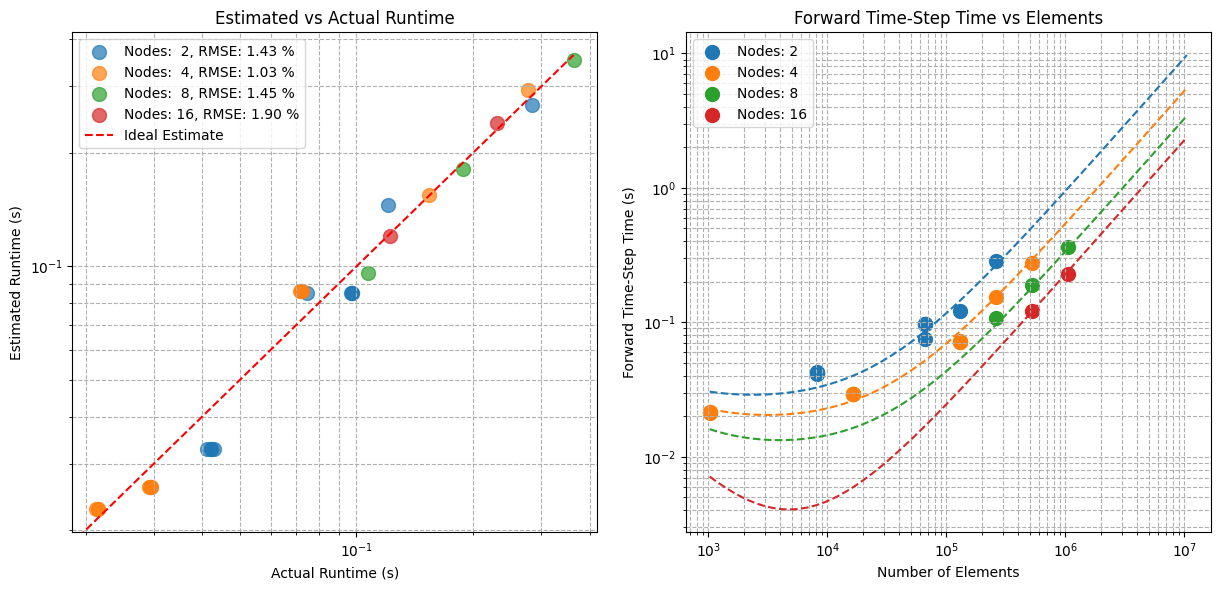

In [363]:
# Estimate the average runtime per forward time step
# This will be a function of the number of elements and nodes

forward_times = extract_times(all_experiments, 'Time-Step')


# Fit a polynomial model to predict optimizer time
def forward_times_fun(N: int, nodes: int, coeffs=None):
    n = float(N)
    no = float(nodes)

    x = np.array([n, no, 1 / n, 1 / no, n / no, 1.0])
    if coeffs is not None:
        x = x * coeffs[:len(x)]
    return x


# Construct a mask with the unique combinations of parameters
# - Number of elements
# - Checkpoint interval
# - Number of nodes
y = np.array([])
X = np.zeros((0, len(forward_times_fun(1, 1))))

# Loop through all unique combinations of the three arrays
for numel, nodes in product(all_elements_u, all_nodes_u):
    mask = (all_elements == numel) & (all_nodes == nodes)
    if not np.any(mask):
        continue
    y = np.append(y, forward_times[mask].mean())
    X = np.vstack([X, np.zeros((1, len(forward_times_fun(1, 1))))])
    i = len(y) - 1
    X[i, :] = forward_times_fun(numel, nodes)

# Solve for coefficients using least squares
forward_time_coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
preds = X.dot(forward_time_coeffs)
rmse = np.sqrt(np.mean((preds - y)**2))
print(f"RMSE: {rmse:.3f} s")

runtime_estimator['Forward time-step'] = forward_time_coeffs

# PLot the forward time per time step as a function of elements for each node
# count
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for n in np.unique(all_nodes):
    mask = all_nodes == n
    plt.scatter(all_elements[mask],
                forward_times[mask],
                label=f'Nodes: {n}',
                s=100)
    x_times = np.logspace(log(min(all_elements), 10),
                          log(max(all_elements), 10) + 1, 100)
    y_times = [
        forward_times_fun(e, n, forward_time_coeffs).sum() for e in x_times
    ]
    plt.plot(x_times, y_times, linestyle='--')

plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Elements')
plt.ylabel('Forward Time-Step Time (s)')
plt.title('Forward Time-Step Time vs Elements')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()

plt.sca(ax[0])
for nodes in all_nodes_u:
    mask = (all_nodes == nodes)
    estimated_runtimes = np.array([
        forward_times_fun(e, nodes, forward_time_coeffs).sum()
        for e in all_elements
    ])
    actual_runtimes = forward_times
    if not np.any(mask):
        continue
    rmse = 100 * np.sqrt(
        np.mean((estimated_runtimes[mask] - actual_runtimes[mask])**
                2)) / actual_runtimes[mask].sum()
    plt.scatter(actual_runtimes[mask],
                estimated_runtimes[mask],
                s=100,
                alpha=0.7,
                label=f'Nodes: {nodes:2d}, RMSE: {rmse:.2f} %')

max_time = max(max(actual_runtimes), max(estimated_runtimes))
plt.plot([0, max_time], [0, max_time], 'r--', label='Ideal Estimate')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Actual Runtime (s)')
plt.ylabel('Estimated Runtime (s)')
plt.title('Estimated vs Actual Runtime')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

RMSE: 0.001 s


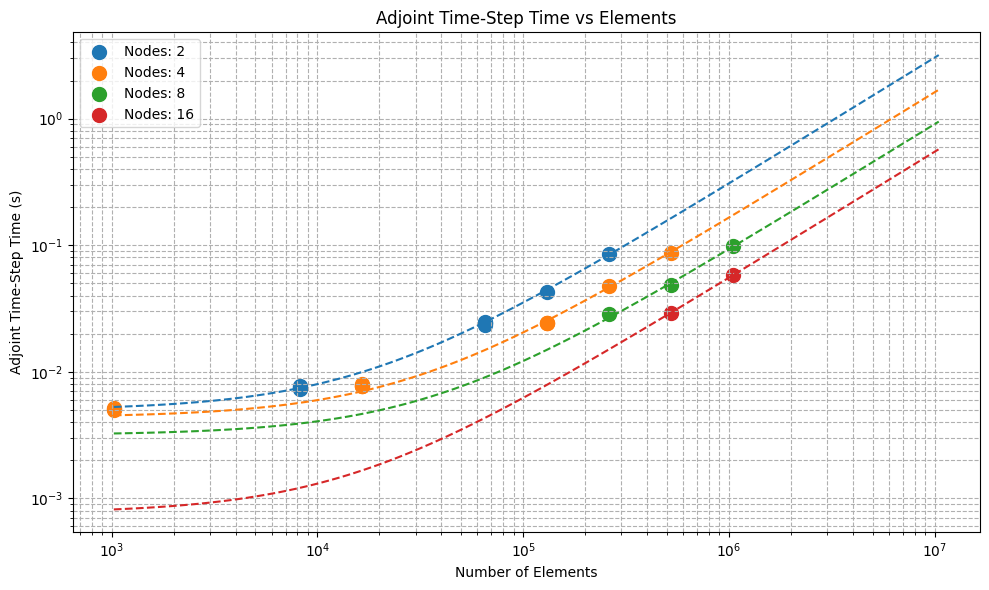

In [348]:
# Estimate the average runtime per adjoint time step
# This will be a function of the number of elements and nodes

adjoint_times = extract_times(all_experiments, 'Time-Step Adjoint')


# Fit a polynomial model to predict optimizer time
def adjoint_times_fun(N: int, nodes: int, coeffs=None):
    n = float(N)
    no = float(nodes)

    x = np.array([n, no, n / no, 1.0])

    if coeffs is not None:
        x = x * coeffs[:len(x)]
    return x


# Construct a mask with the unique combinations of parameters
# - Number of elements
# - Checkpoint interval
# - Number of nodes
y = np.array([])
X = np.zeros((0, len(adjoint_times_fun(1, 1))))

# Loop through all unique combinations of the three arrays
for numel, nodes in product(all_elements_u, all_nodes_u):
    mask = (all_elements == numel) & (all_nodes == nodes)
    if not np.any(mask):
        continue
    y = np.append(y, adjoint_times[mask].mean())
    X = np.vstack([X, np.zeros((1, len(adjoint_times_fun(1, 1))))])
    i = len(y) - 1
    X[i, :] = adjoint_times_fun(numel, nodes)

# Solve for coefficients using least squares
adjoint_time_coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
preds = X.dot(adjoint_time_coeffs)
rmse = np.sqrt(np.mean((preds - y)**2))
print(f"RMSE: {rmse:.3f} s")

runtime_estimator['Adjoint time-step'] = adjoint_time_coeffs

# PLot the forward time per time step as a function of elements for each node
# count
plt.figure(figsize=(10, 6))
for n in np.unique(all_nodes):
    mask = all_nodes == n
    plt.scatter(all_elements[mask],
                adjoint_times[mask],
                label=f'Nodes: {n}',
                s=100)
    x_times = np.logspace(log(min(all_elements), 10),
                          log(max(all_elements), 10) + 1, 100)
    y_times = [
        adjoint_times_fun(e, n, adjoint_time_coeffs).sum() for e in x_times
    ]
    plt.plot(x_times, y_times, linestyle='--')

plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Elements')
plt.ylabel('Adjoint Time-Step Time (s)')
plt.title('Adjoint Time-Step Time vs Elements')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

RMSE: 3.454 s


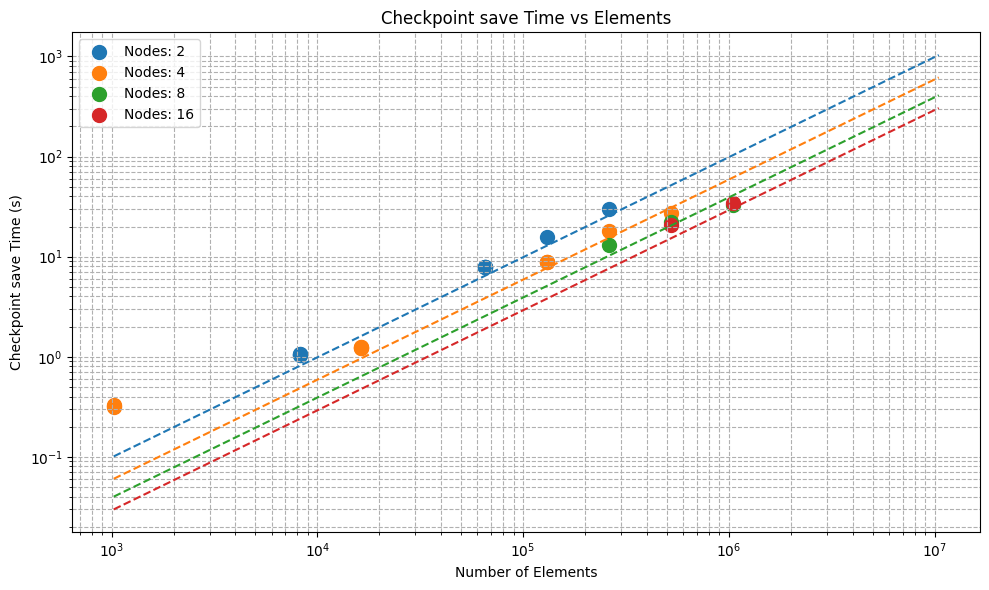

In [349]:
# Estimate the average runtime per checkpoint save
# This will be a function of the number of elements and nodes

checkpoint_save_times = extract_times(all_experiments, 'Checkpoint save',
                                      'Total time')

total_tsteps = np.ceil(1e-1 / 1e-4)
nc = np.array(tsteps // all_memory, dtype=float) + 2.0

checkpoint_save_times = checkpoint_save_times / nc


# Fit a polynomial model to predict optimizer time
def checkpoint_save_times_fun(N: int, nodes: int, coeffs=None):
    n = float(N)
    no = float(nodes)

    x = np.array([n, n / no])
    if coeffs is not None:
        x = x * coeffs[:len(x)]
    return x


# Construct a mask with the unique combinations of parameters
# - Number of elements
# - Checkpoint interval
# - Number of nodes
y = np.array([])
X = np.zeros((0, len(checkpoint_save_times_fun(1, 1))))

# Loop through all unique combinations of the three arrays
for numel, nodes in product(all_elements_u, all_nodes_u):
    mask = (all_elements == numel) & (all_nodes == nodes)
    if not np.any(mask):
        continue
    y = np.append(y, checkpoint_save_times[mask].mean())
    X = np.vstack([X, np.zeros((1, len(checkpoint_save_times_fun(1, 1))))])
    i = len(y) - 1
    X[i, :] = checkpoint_save_times_fun(numel, nodes)

# Solve for coefficients using least squares
checkpoint_save_time_coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
preds = X.dot(checkpoint_save_time_coeffs)
rmse = np.sqrt(np.mean((preds - y)**2))
print(f"RMSE: {rmse:.3f} s")

runtime_estimator['Checkpoint save'] = checkpoint_save_time_coeffs

# PLot the forward time per time step as a function of elements for each node
# count
plt.figure(figsize=(10, 6))
for n in np.unique(all_nodes):
    mask = all_nodes == n
    plt.scatter(all_elements[mask],
                checkpoint_save_times[mask],
                label=f'Nodes: {n}',
                s=100)
    x_times = np.logspace(log(min(all_elements), 10),
                          log(max(all_elements), 10) + 1, 100)
    y_times = [
        checkpoint_save_times_fun(e, n, checkpoint_save_time_coeffs).sum()
        for e in x_times
    ]
    plt.plot(x_times, y_times, linestyle='--')

plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Elements')
plt.ylabel('Checkpoint save Time (s)')
plt.title('Checkpoint save Time vs Elements')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

RMSE: 0.172 s


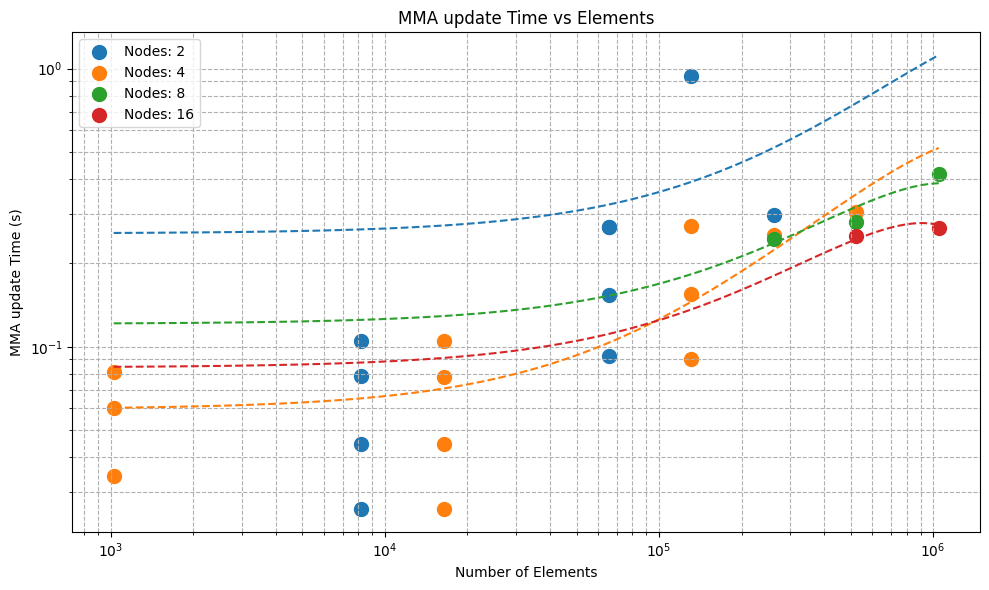

In [350]:
# Estimate the average runtime per MMA update
# This will be a function of the number of elements and nodes

mma_update_times = extract_times(all_experiments, 'MMA update')

total_tsteps = 1e-1 / 1e-4
nc = np.array(tsteps // all_memory, dtype=float) + 2

mma_update_times = mma_update_times / nc


# Fit a polynomial model to predict optimizer time
def mma_update_times_fun(N: int, nodes: int, coeffs=None):
    n = float(N)
    no = float(nodes)

    x = np.array(
        [n, no, 1 / n, 1 / no, n**2, no**2,
         log(no), n / no, n * no, 1.0])
    if coeffs is not None:
        x = x * coeffs[:len(x)]
    return x


# Construct a mask with the unique combinations of parameters
# - Number of elements
# - Checkpoint interval
# - Number of nodes
y = np.array([])
X = np.zeros((0, len(mma_update_times_fun(1, 1))))

# Loop through all unique combinations of the three arrays
for numel, nodes in product(all_elements_u, all_nodes_u):
    mask = (all_elements == numel) & (all_nodes == nodes)
    if not np.any(mask):
        continue
    y = np.append(y, mma_update_times[mask].mean())
    X = np.vstack([X, np.zeros((1, len(mma_update_times_fun(1, 1))))])
    i = len(y) - 1
    X[i, :] = mma_update_times_fun(numel, nodes)

# Solve for coefficients using least squares
mma_update_time_coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
preds = X.dot(mma_update_time_coeffs)
rmse = np.sqrt(np.mean((preds - y)**2))
print(f"RMSE: {rmse:.3f} s")

runtime_estimator['MMA update'] = mma_update_time_coeffs

# PLot the forward time per time step as a function of elements for each node
# count
plt.figure(figsize=(10, 6))
for n in np.unique(all_nodes):
    mask = all_nodes == n
    plt.scatter(all_elements[mask],
                mma_update_times[mask],
                label=f'Nodes: {n}',
                s=100)
    x_times = np.logspace(log(min(all_elements), 10),
                          log(max(all_elements), 10), 100)
    y_times = [
        mma_update_times_fun(e, n, mma_update_time_coeffs).sum()
        for e in x_times
    ]
    plt.plot(x_times, y_times, linestyle='--')

plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Elements')
plt.ylabel('MMA update Time (s)')
plt.title('MMA update Time vs Elements')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

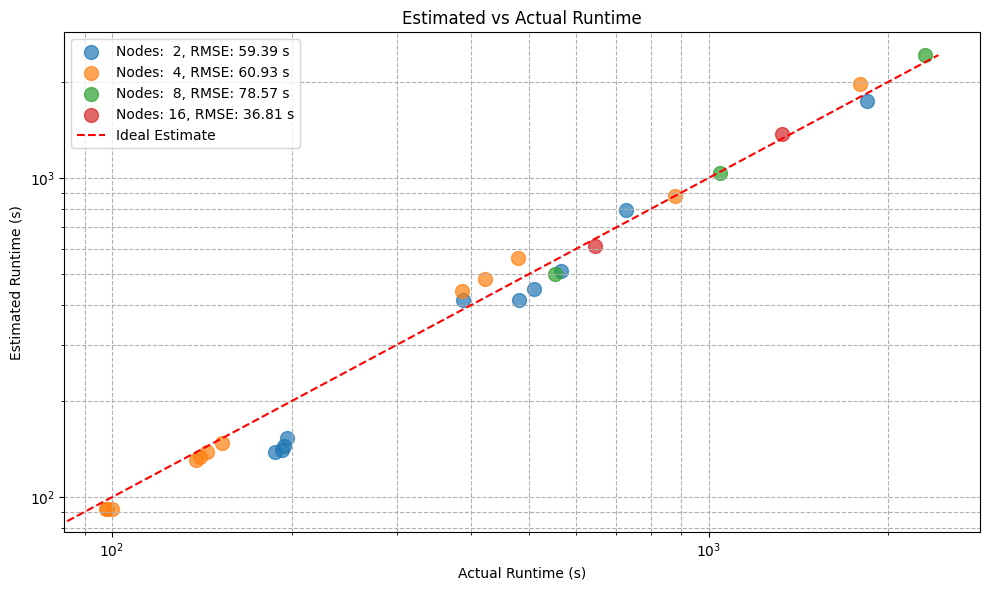

In [351]:
# Build an estimator based on the collected coefficients
def estimate_runtime(num_elements: int, num_nodes: int,
                     checkpoint_interval: int, num_time_steps: int,
                     num_iterations: int, runtime_estimator: dict) -> float:
    """
    Estimate the total runtime based on the number of elements, nodes,
    checkpoints, and time steps.

    Args:
        num_elements (int): Number of elements in the simulation.
        num_nodes (int): Number of nodes used.
        num_checkpoints (int): Number of checkpoints.
        num_time_steps (int): Number of time steps.
        runtime_estimator (dict): Dictionary containing the coefficients for
                                   each component.
    Returns:
        float: Estimated total runtime in seconds.
    """

    forward_time_coeffs = runtime_estimator['Forward time-step']
    adjoint_time_coeffs = runtime_estimator['Adjoint time-step']
    checkpoint_save_time_coeffs = runtime_estimator['Checkpoint save']

    forward_time = forward_times_fun(num_elements, num_nodes,
                                     forward_time_coeffs).sum()
    adjoint_time = adjoint_times_fun(num_elements, num_nodes,
                                     adjoint_time_coeffs).sum()
    checkpoint_save_time = checkpoint_save_times_fun(
        num_elements, num_nodes, checkpoint_save_time_coeffs).sum()

    total_runtime = (2.0 * forward_time + adjoint_time) * num_time_steps
    total_runtime += checkpoint_save_time * num_time_steps / checkpoint_interval
    total_runtime *= num_iterations
    return total_runtime


# Plot the estimate minus actual runtime for all experiments
estimated_runtimes = np.array([
    estimate_runtime(exp['Nx'] * exp['Ny'] * exp['Nz'], exp['nodes'],
                     exp['N_memory'], 1000, 2, runtime_estimator)
    for exp in all_experiments if exp['status'] == 'done'
])
actual_runtimes = extract_times(all_experiments, 'Optimizer iteration',
                                'Total time')

plt.figure(figsize=(10, 6))

for nodes in all_nodes_u:
    mask = (all_nodes == nodes)
    if not np.any(mask):
        continue
    rmse = np.sqrt(
        np.mean((estimated_runtimes[mask] - actual_runtimes[mask])**2))
    plt.scatter(actual_runtimes[mask],
                estimated_runtimes[mask],
                s=100,
                alpha=0.7,
                label=f'Nodes: {nodes:2d}, RMSE: {rmse:.2f} s')

max_time = max(max(actual_runtimes), max(estimated_runtimes))
plt.plot([0, max_time], [0, max_time], 'r--', label='Ideal Estimate')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Actual Runtime (s)')
plt.ylabel('Estimated Runtime (s)')
plt.title('Estimated vs Actual Runtime')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

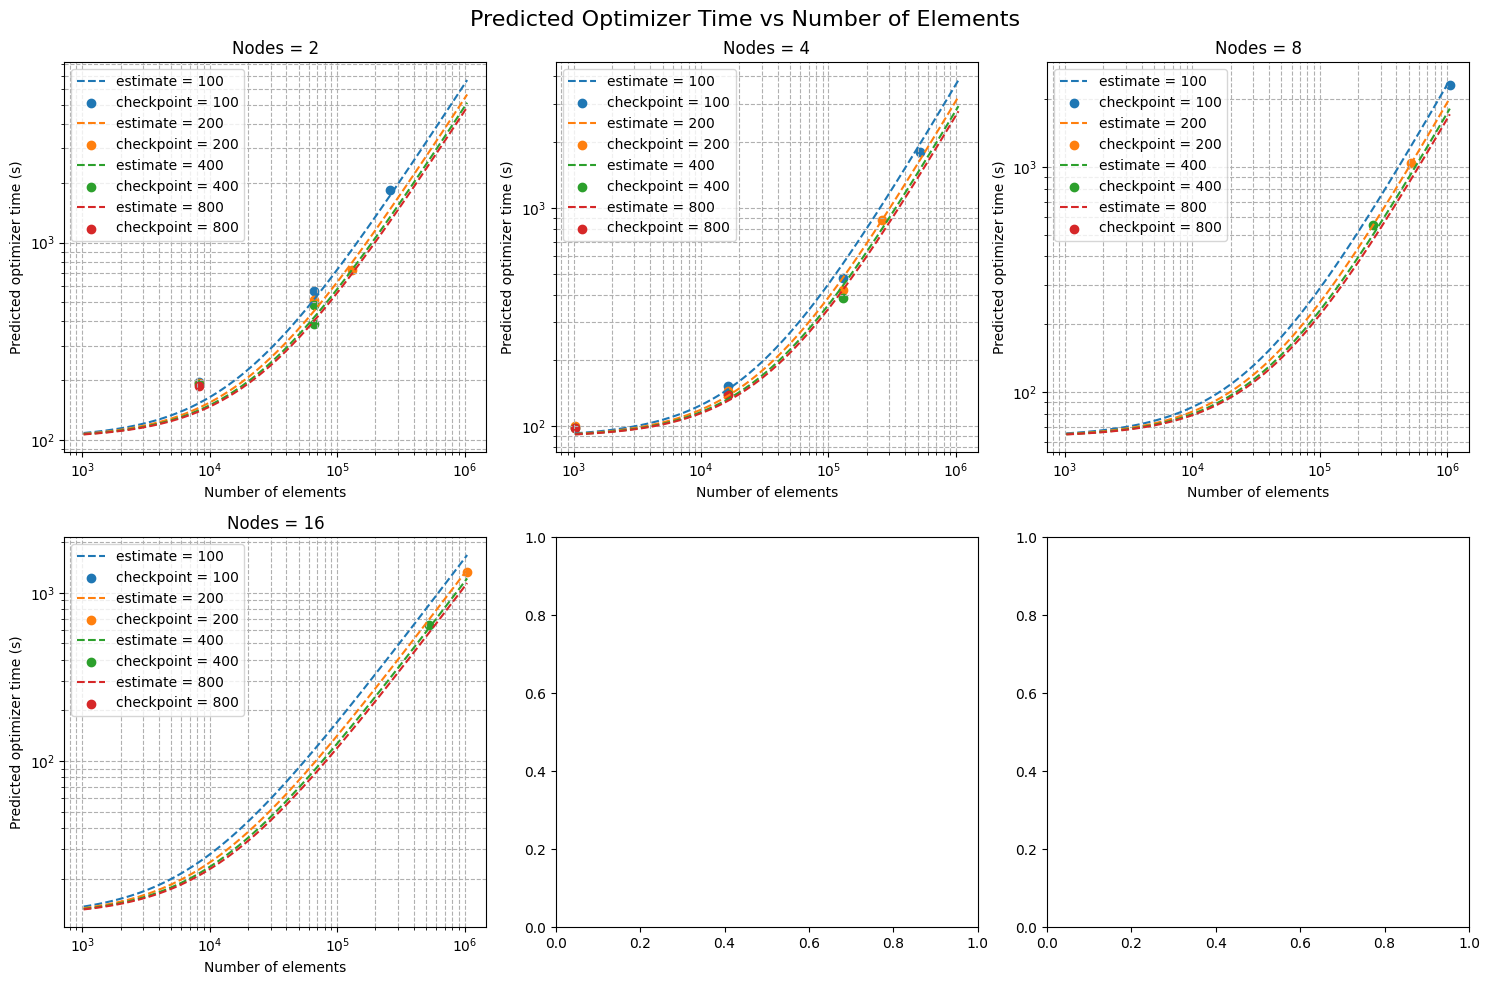

In [352]:
# We need to rethink this approach a bit. It might be better to split the time
# into the components and model them separately.
# - Time Step, will be dependent on elements, nodes and end time.
# - Adjoint Time Step, will be dependent on elements, nodes and end time.
# - Checkpoint save/restore, will be dependent on elements, nodes and number of
#   checkpoints.
# - Overhead can probably be modelled based on the final time and our estimates.
# Optimizer time can then be modelled as the sum of these components.

# Plot 2: Row of predicted times vs number of elements for different nodes.
# Every plot line corresponds to a different checkpoint interval.

n_col = 3
n_row = len(all_nodes_u) // n_col + 1
fig, ax = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))
fig.suptitle('Predicted Optimizer Time vs Number of Elements', fontsize=16)
for i, nodes in enumerate(all_nodes_u):
    for chk in all_memory_u:

        mask = (all_memory == chk) & (all_nodes == nodes)
        x_axis = np.logspace(log(min(all_elements_u), 10),
                             log(max(all_elements_u), 10), 100)

        p = [
            estimate_runtime(N, nodes, chk, 1000, 2, runtime_estimator)
            for N in x_axis
        ]

        axi = ax[i // 3, i - (i // 3) * 3]

        axi.plot(x_axis,
                 p,
                 marker='',
                 label=f'estimate = {chk}',
                 linestyle='--')
        axi.scatter(all_elements[mask],
                    actual_runtimes[mask],
                    label=f'checkpoint = {chk}')

for i, nodes in enumerate(all_nodes_u):
    axi = ax[i // 3, i - (i // 3) * 3]
    mask = (all_memory == chk) & (all_nodes == nodes)

    axi.set_title(f'Nodes = {nodes}')
    axi.set_xscale('log', base=10)
    axi.set_yscale('log', base=10)
    axi.set_xlabel('Number of elements')
    axi.set_ylabel('Predicted optimizer time (s)')
    # axi.set_xlim(0.9 * min(nodes * 4 * 1e4, min(all_elements[mask])),
    #              max(all_elements[mask]) * 1.1)
    # axi.set_ylim(
    #     min(actual_runtimes[mask]) * 0.9,
    #     max(actual_runtimes[mask]) * 1.1)
    axi.legend()
    axi.grid(True, which="both", ls="--")

plt.tight_layout()

In [353]:
def print_runtime_estimate(case: dict):

    def wall_time(time):
        secs = int(round(float(time)))
        days, rem = divmod(secs, 86400)
        hours, rem = divmod(rem, 3600)
        minutes, seconds = divmod(rem, 60)
        if days:
            return f"{days}d-{hours:02d}:{minutes:02d}:{seconds:02d}"
        return f"{hours:02d}:{minutes:02d}:{seconds:02d}"

    numel = case['num_elements']
    checkpoints = case['c_interval']
    end_time = case['end_time']
    timestep = case['step_size']
    nodes = case['nodes']
    o_iterations = case['o_iterations']

    # Print the estimated time and nodes
    p = estimate_runtime(numel, nodes, checkpoints, end_time / timestep,
                         o_iterations, runtime_estimator)

    # Check if the estimate is valid
    if p / o_iterations / 3600 > 48:
        print("Warning: Estimated wall time per iteration exceeds 48 hours.")

    print(f"Estimated runtime for case:")
    print(f"  Wall Time per iteration: {p / o_iterations /3600:,.3f} hrs.")
    print(f"  Wall time: {wall_time(p)}")
    print(f"  Node hours: {p * nodes / 3600:,.0f} hrs.")


# Storage Testing


In [354]:
storage_experiment = read_experiment_file('storage_test.csv')

In [355]:
def file_size_string(n, precision=0):
    for unit in ('B', 'KB', 'MB', 'GB', 'TB'):
        if n < 1024.0:
            return f"{n:.{precision}f}{unit}"
        n /= 1024.0
    return f"{n:.{precision}f}PB"

In [356]:
# Determine the files sizes relevant for the storage requirements

# Look the the result folder and determine the filesize of the checkpoints
for exp in storage_experiment:
    if exp['status'] != 'done':
        continue
    if 'checkpoint_size' in exp:
        continue

    result_folder = os.path.join(RESULT_DIR, exp['case_name'], 'checkpoints')
    if not os.path.exists(result_folder):
        exp['checkpoint_size'] = 0.0
        continue

    pattern = re.compile(r'.*\.(chkp|h5)$')
    total_size = 0
    num_files = 0
    for file in os.listdir(result_folder):
        if pattern.match(file):
            file_path = os.path.join(result_folder, file)
            total_size += os.path.getsize(file_path)
            num_files += 1
    average_size = total_size / num_files if num_files > 0 else 0
    exp['checkpoint_size'] = average_size

    if 'checkpoint_size' not in exp:
        raise ValueError(
            f"Could not determine checkpoint size for experiment {exp['case_name']}"
        )

# Look at the design files and estimate their size
for exp in storage_experiment:
    if exp['status'] != 'done':
        continue
    if 'design0_size' in exp and 'design_size' in exp:
        continue

    result_folder = os.path.join(RESULT_DIR, exp['case_name'], 'design0')
    if not os.path.exists(result_folder):
        exp['design0_size'] = 0.0
        exp['design_size'] = 0.0
        continue

    pattern0 = re.compile(r'design0\.f0+$')
    pattern = re.compile(r'design0\.f[0-9]+$')
    design_total = 0
    design_count = 0

    for file in os.listdir(result_folder):
        if pattern0.match(file):
            file_path = os.path.join(result_folder, file)
            exp['design0_size'] = os.path.getsize(file_path)

        elif pattern.match(file):
            file_path = os.path.join(result_folder, file)
            design_total += os.path.getsize(file_path)
            design_count += 1

    average_design_size = design_total / design_count if design_count > 0 else 0
    exp['design_size'] = average_design_size

    if 'design0_size' not in exp:
        raise ValueError(
            f"Could not determine design0 size for experiment {exp['case_name']}"
        )
    if 'design_size' not in exp:
        raise ValueError(
            f"Could not determine design size for experiment {exp['case_name']}"
        )

# Look at the forward fluid fields to determine their size
for exp in storage_experiment:
    if exp['status'] != 'done':
        continue
    if 'fluid0_size' in exp and 'fluid_size' in exp:
        continue

    result_folder = os.path.join(RESULT_DIR, exp['case_name'],
                                 'forward_fields0')
    if not os.path.exists(result_folder):
        exp['fluid0_size'] = 0.0
        exp['fluid_size'] = 0.0
        continue

    pattern0 = re.compile(r'forward_fields0\.f0+$')
    pattern = re.compile(r'forward_fields0\.f[0-9]+$')
    fluid_total = 0
    fluid_count = 0

    for file in os.listdir(result_folder):
        if pattern0.match(file):
            file_path = os.path.join(result_folder, file)
            exp['fluid0_size'] = os.path.getsize(file_path)
        elif pattern.match(file):
            file_path = os.path.join(result_folder, file)
            fluid_total += os.path.getsize(file_path)
            fluid_count += 1

    average_fluid_size = fluid_total / fluid_count if fluid_count > 0 else 0
    exp['fluid_size'] = average_fluid_size

    if 'fluid0_size' not in exp:
        raise ValueError(
            f"Could not determine fluid0 size for experiment {exp['case_name']}"
        )
    if 'fluid_size' not in exp:
        raise ValueError(
            f"Could not determine fluid size for experiment {exp['case_name']}"
        )

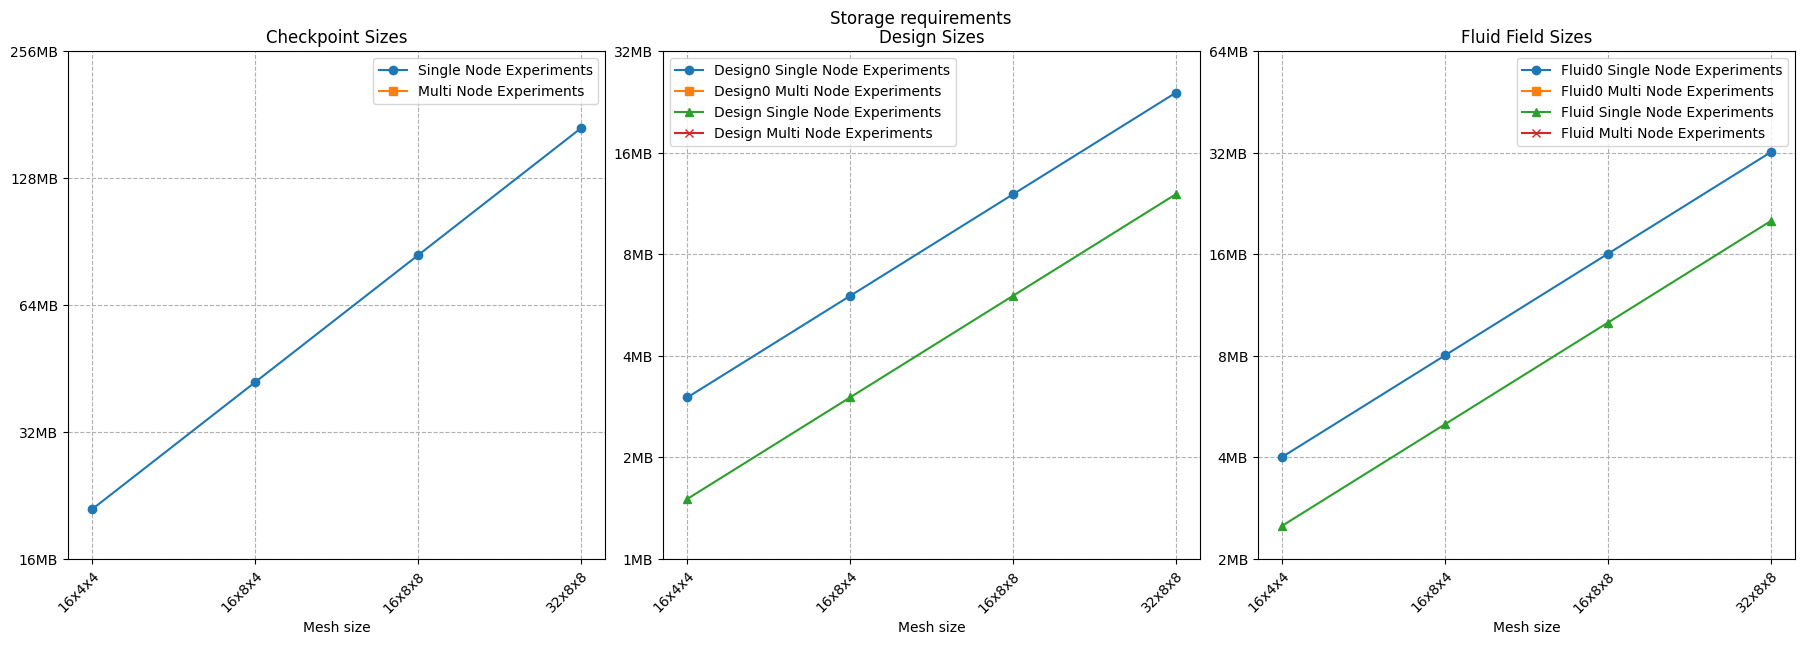

In [357]:
# Visualize the checkpoint sizes and estimate function for predicting storage
# requirements
storage_mesh_labels = np.array([
    f"{exp['Nx']}x{exp['Ny']}x{exp['Nz']}" for exp in storage_experiment
    if exp['status'] == 'done'
])
storage_num_nodes = np.array(
    [exp['nodes'] for exp in storage_experiment if exp['status'] == 'done'])
storage_num_elements = np.array([
    exp['Nx'] * exp['Ny'] * exp['Nz'] for exp in storage_experiment
    if exp['status'] == 'done'
])

# Get the sizes
checkpoint_size = np.array([
    exp['checkpoint_size'] for exp in storage_experiment
    if exp['status'] == 'done'
])
design0_size = np.array([
    exp['design0_size'] for exp in storage_experiment
    if exp['status'] == 'done'
])
design_size = np.array([
    exp['design_size'] for exp in storage_experiment if exp['status'] == 'done'
])
fluid0_size = np.array([
    exp['fluid0_size'] for exp in storage_experiment if exp['status'] == 'done'
])
fluid_size = np.array([
    exp['fluid_size'] for exp in storage_experiment if exp['status'] == 'done'
])

# Split the lines into single node and multi node
checkpoint_line_1 = checkpoint_size[storage_num_nodes == 1]
checkpoint_line_1_elements = storage_num_elements[storage_num_nodes == 1]
checkpoint_line_2 = checkpoint_size[storage_num_nodes > 1]
checkpoint_line_2_elements = storage_num_elements[storage_num_nodes > 1]
design0_line_1 = design0_size[storage_num_nodes == 1]
design0_line_1_elements = storage_num_elements[storage_num_nodes == 1]
design0_line_2 = design0_size[storage_num_nodes > 1]
design0_line_2_elements = storage_num_elements[storage_num_nodes > 1]
design_line_1 = design_size[storage_num_nodes == 1]
design_line_1_elements = storage_num_elements[storage_num_nodes == 1]
design_line_2 = design_size[storage_num_nodes > 1]
design_line_2_elements = storage_num_elements[storage_num_nodes > 1]
fluid0_line_1 = fluid0_size[storage_num_nodes == 1]
fluid0_line_1_elements = storage_num_elements[storage_num_nodes == 1]
fluid0_line_2 = fluid0_size[storage_num_nodes > 1]
fluid0_line_2_elements = storage_num_elements[storage_num_nodes > 1]
fluid_line_1 = fluid_size[storage_num_nodes == 1]
fluid_line_1_elements = storage_num_elements[storage_num_nodes == 1]
fluid_line_2 = fluid_size[storage_num_nodes > 1]
fluid_line_2_elements = storage_num_elements[storage_num_nodes > 1]

storage_x_axis = np.unique(storage_num_elements)
checkpoint_min = log(min(checkpoint_size), 2)
checkpoint_max = log(max(checkpoint_size), 2) + 2
design_min = log(min(min(design0_size), min(design_size)), 2)
design_max = log(max(max(design0_size), max(design_size)), 2) + 2
fluid_min = log(min(min(fluid0_size), min(fluid_size)), 2)
fluid_max = log(max(max(fluid0_size), max(fluid_size)), 2) + 2
checkpoint_y_axis = [
    2**i for i in range(int(checkpoint_min), int(checkpoint_max))
]
design_y_axis = [2**i for i in range(int(design_min), int(design_max))]
fluid_y_axis = [2**i for i in range(int(fluid_min), int(fluid_max))]

checkpoint_y_axis_label = [file_size_string(y) for y in checkpoint_y_axis]
design_y_axis_label = [file_size_string(y) for y in design_y_axis]
fluid_y_axis_label = [file_size_string(y) for y in fluid_y_axis]

# Create the plots
[fig_storage, ax_storage] = plt.subplots(1, 3, figsize=(18, 6))
fig_storage.suptitle('Storage requirements')
fig_storage.tight_layout()

# Assign common settings to all subplots
for ax in ax_storage:
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)

# Plot the checkpoint sizes
ax_storage[0].plot(checkpoint_line_1_elements,
                   checkpoint_line_1,
                   marker='o',
                   label='Single Node Experiments')
ax_storage[0].plot(checkpoint_line_2_elements,
                   checkpoint_line_2,
                   marker='s',
                   label='Multi Node Experiments')

ax_storage[0].set_title('Checkpoint Sizes')
ax_storage[0].set_yticks(checkpoint_y_axis, checkpoint_y_axis_label)

# Plot the design sizes
ax_storage[1].plot(design0_line_1_elements,
                   design0_line_1,
                   marker='o',
                   label='Design0 Single Node Experiments')
ax_storage[1].plot(design0_line_2_elements,
                   design0_line_2,
                   marker='s',
                   label='Design0 Multi Node Experiments')
ax_storage[1].plot(design_line_1_elements,
                   design_line_1,
                   marker='^',
                   label='Design Single Node Experiments')
ax_storage[1].plot(design_line_2_elements,
                   design_line_2,
                   marker='x',
                   label='Design Multi Node Experiments')

ax_storage[1].set_title('Design Sizes')
ax_storage[1].set_yticks(design_y_axis, design_y_axis_label)

# Plot the fluid field sizes
ax_storage[2].plot(fluid0_line_1_elements,
                   fluid0_line_1,
                   marker='o',
                   label='Fluid0 Single Node Experiments')
ax_storage[2].plot(fluid0_line_2_elements,
                   fluid0_line_2,
                   marker='s',
                   label='Fluid0 Multi Node Experiments')
ax_storage[2].plot(fluid_line_1_elements,
                   fluid_line_1,
                   marker='^',
                   label='Fluid Single Node Experiments')
ax_storage[2].plot(fluid_line_2_elements,
                   fluid_line_2,
                   marker='x',
                   label='Fluid Multi Node Experiments')

ax_storage[2].set_title('Fluid Field Sizes')
ax_storage[2].set_yticks(fluid_y_axis, fluid_y_axis_label)

# Assign common settings to all subplots
for ax in ax_storage:
    ax.set_xlabel('Mesh size')
    ax.set_xticks(storage_x_axis,
                  storage_mesh_labels,
                  ha='right',
                  rotation_mode='anchor',
                  rotation=45)

    ax.grid(True, which="both", ls="--")
    ax.legend()


In [358]:
# Estimate functions for the storage requirements

# Estimate A and B in the model size = A * N + B
# where N is the number of elements using linear regression on the single node
# experiments
try:
    checkpoint_a1, checkpoint_b1 = np.polyfit(checkpoint_line_1_elements,
                                              checkpoint_line_1, 1)
except Exception as e:
    checkpoint_a1, checkpoint_b1 = 0.0, 0.0
try:
    checkpoint_a2, checkpoint_b2 = np.polyfit(checkpoint_line_2_elements,
                                              checkpoint_line_2, 1)
except Exception as e:
    checkpoint_a2, checkpoint_b2 = 0.0, 0.0
try:
    design0_a1, design0_b1 = np.polyfit(design0_line_1_elements,
                                        design0_line_1, 1)
except Exception as e:
    design0_a1, design0_b1 = 0.0, 0.0
try:
    design0_a2, design0_b2 = np.polyfit(design0_line_2_elements,
                                        design0_line_2, 1)
except Exception as e:
    design0_a2, design0_b2 = 0.0, 0.0
try:
    design_a1, design_b1 = np.polyfit(design_line_1_elements, design_line_1, 1)
except Exception as e:
    design_a1, design_b1 = 0.0, 0.0
try:
    design_a2, design_b2 = np.polyfit(design_line_2_elements, design_line_2, 1)
except Exception as e:
    design_a2, design_b2 = 0.0, 0.0
try:
    fluid0_a1, fluid0_b1 = np.polyfit(fluid0_line_1_elements, fluid0_line_1, 1)
except Exception as e:
    fluid0_a1, fluid0_b1 = 0.0, 0.0
try:
    fluid0_a2, fluid0_b2 = np.polyfit(fluid0_line_2_elements, fluid0_line_2, 1)
except Exception as e:
    fluid0_a2, fluid0_b2 = 0.0, 0.0
try:
    fluid_a1, fluid_b1 = np.polyfit(fluid_line_1_elements, fluid_line_1, 1)
except Exception as e:
    fluid_a1, fluid_b1 = 0.0, 0.0
try:
    fluid_a2, fluid_b2 = np.polyfit(fluid_line_2_elements, fluid_line_2, 1)
except Exception as e:
    fluid_a2, fluid_b2 = 0.0, 0.0

storage_estimator = {
    'checkpoint': {
        'single_node': (checkpoint_a1, checkpoint_b1),
        'multi_node': (checkpoint_a2, checkpoint_b2)
    },
    'design0': {
        'single_node': (design0_a1, design0_b1),
        'multi_node': (design0_a2, design0_b2)
    },
    'design': {
        'single_node': (design_a1, design_b1),
        'multi_node': (design_a2, design_b2)
    },
    'fluid0': {
        'single_node': (fluid0_a1, fluid0_b1),
        'multi_node': (fluid0_a2, fluid0_b2)
    },
    'fluid': {
        'single_node': (fluid_a1, fluid_b1),
        'multi_node': (fluid_a2, fluid_b2)
    }
}
if DEBUG:
    print("Storage Estimator Parameters:")
    for key, value in storage_estimator.items():
        print(f"  {key}:")
        for subkey, subvalue in value.items():
            print(f"    {subkey}: A={subvalue[0]:.2e}, B={subvalue[1]:.2e}")

In [359]:
def print_storage_estimate(storage_estimator, num_elements: int,
                           end_time: float, step_size: float, c_interval: int,
                           o_iterations: int, f_interval: float):
    """
    Print the estimated storage requirements based on the provided parameters.

    Args:
        storage_estimator (dict): Dictionary containing storage estimation
                                  parameters.
        num_elements (int): Number of elements in the mesh.
        end_time (float): End time of the simulation.
        step_size (float): Time step size.
        c_interval (int): Checkpoint interval in number of time steps.
        o_iterations (int): Number of optimizer iterations.
        f_interval (float): Fluid field save interval in time units.
    """

    num_checkpoints: int = int(np.ceil(end_time / step_size) / c_interval) + 2
    num_designs: int = o_iterations
    num_fluid_fields: int = int(end_time / f_interval)

    print(f"Storage estimate:")
    total_size_1 = 0.0
    archive_size_1 = 0.0
    total_size_2 = 0.0
    archive_size_2 = 0.0
    total_count: int = 0
    archive_count: int = 0

    for key, value in storage_estimator.items():
        if 'single_node' in value:
            a1, b1 = value['single_node']
            storage_1 = a1 * num_elements + b1

            type_archive = True
            if key == 'checkpoint':
                type_count = num_checkpoints
                type_archive = False
            elif key == 'design':
                type_count = num_designs
                type_archive = True
            elif key == 'fluid':
                type_count = num_fluid_fields
                type_archive = True
            else:
                type_count = 1
                type_archive = True

            storage_1 *= type_count
            if storage_1 > 0:
                print(
                    f"  {type_count:6,} {key} single node: {file_size_string(storage_1, 2)}"
                )

                total_size_1 += storage_1
                total_count += type_count
                archive_size_1 += type_archive * storage_1
                archive_count += type_archive * type_count

        if 'multi_node' in value:
            a2, b2 = value['multi_node']
            storage_2 = a2 * num_elements + b2

            type_archive = True
            if key == 'checkpoint':
                type_count = num_checkpoints
                type_archive = False
            elif key == 'design':
                type_count = num_designs
                type_archive = True
            elif key == 'fluid':
                type_count = num_fluid_fields
                type_archive = True
            else:
                type_count = 1
                type_archive = True

            storage_2 *= type_count
            if storage_2 > 0:
                print(
                    f"  {type_count:6,} {key} multi node: {file_size_string(storage_2, 2)}"
                )

                total_size_2 += storage_2
                total_count += type_count

                archive_size_2 += type_archive * storage_2
                archive_count += type_archive * type_count

    if archive_size_1 > 0:
        print(f"  Archive size single: {file_size_string(archive_size_1, 2)}")
    if archive_size_2 > 0:
        print(f"  Archive size multi: {file_size_string(archive_size_2, 2)}")
    if total_size_1 > 0:
        print(f"  Total storage single: {file_size_string(total_size_1, 2)}")
    if total_size_2 > 0:
        print(f"  Total storage multi: {file_size_string(total_size_2, 2)}")

    if total_count > 0:
        print(f"  Total files: {total_count}")
    if archive_count > 0:
        print(f"  Total archive files: {archive_count}")


def print_storage_estimate_case(storage_estimator: dict, case: dict):
    """
    Print the estimated storage requirements based on the provided parameters.

    Args:
        storage_estimator (dict): Dictionary containing storage estimation
                                  parameters.
        case (dict): Dictionary containing case parameters:
            num_elements (int): Number of elements in the mesh.
            end_time (float): End time of the simulation.
            step_size (float): Time step size.
            c_interval (int): Checkpoint interval in number of time steps.
            o_iterations (int): Number of optimizer iterations.
            f_interval (float): Fluid field save interval in time units.
    """

    if 'num_elements' in case:
        num_elements = case['num_elements']
    else:
        num_elements = case['Nx'] * case['Ny'] * case['Nz']
    end_time = case['end_time']
    step_size = case['step_size']
    c_interval = case['c_interval']
    o_iterations = case['o_iterations']
    f_interval = case['f_interval']

    print_storage_estimate(storage_estimator,
                           num_elements=num_elements,
                           end_time=end_time,
                           step_size=step_size,
                           c_interval=c_interval,
                           o_iterations=o_iterations,
                           f_interval=f_interval)

In [360]:
def print_dof_estimate(case: dict):
    """
    Print the estimated degrees of freedom based on the provided parameters.

    Args:
        case (dict): Dictionary containing case parameters:
            num_elements (int): Number of elements in the mesh.
            order (int): Polynomial order of the elements.
    """

    num_elements = case['num_elements']
    order = case['order']
    dof_per_gll = 5  # 3 velocity + pressure + temperature

    num_gll = num_elements * order**3
    forward_dofs = num_gll * dof_per_gll
    adjoint_dofs = num_gll * dof_per_gll
    design_dofs = num_gll
    total_dof = forward_dofs + adjoint_dofs + design_dofs

    print(f"Degrees of Freedom estimate for case:")
    print(f"  Number of Elements: {num_elements:,}")
    print(f"  Forward DOFs: {forward_dofs:,}")
    print(f"  Adjoint DOFs: {adjoint_dofs:,}")
    print(f"  Design DOFs: {design_dofs:,}")
    print(f"  Total DOFs: {total_dof:,}")

# Estimations for the furture cases

In [361]:
# Estimate the storage requirements for specific cases
case_1 = {
    "num_elements": 256 * 64 * 64,
    "order": 7,
    "nodes": 10,
    "end_time": 12,
    "step_size": 1e-4,
    "o_iterations": 400,
    "c_interval": 100,
    "f_interval": 1e-1
}

print_runtime_estimate(case_1)
print_dof_estimate(case_1)
print_storage_estimate_case(storage_estimator, case_1)


Estimated runtime for case:
  Wall Time per iteration: 35.546 hrs.
  Wall time: 592d-10:27:31
  Node hours: 142,185 hrs.
Degrees of Freedom estimate for case:
  Number of Elements: 1,048,576
  Forward DOFs: 1,798,307,840
  Adjoint DOFs: 1,798,307,840
  Design DOFs: 359,661,568
  Total DOFs: 3,956,277,248
Storage estimate:
   1,202 checkpoint single node: 98.60TB
       1 design0 single node: 12.05GB
     400 design single node: 2.35TB
       1 fluid0 single node: 16.07GB
     120 fluid single node: 1.18TB
  Archive size single: 3.56TB
  Total storage single: 102.16TB
  Total files: 1724
  Total archive files: 522


In [362]:
# Estimate the storage requirements for specific cases
case_2 = {
    "num_elements": 512 * 64 * 64,
    "order": 7,
    "nodes": 64,
    "end_time": 12,
    "step_size": 1e-4,
    "o_iterations": 400,
    "c_interval": 100,
    "f_interval": 1e-1
}

print_runtime_estimate(case_2)
print_dof_estimate(case_2)
print_storage_estimate_case(storage_estimator, case_2)


Estimated runtime for case:
  Wall Time per iteration: 32.959 hrs.
  Wall time: 549d-07:30:09
  Node hours: 843,744 hrs.
Degrees of Freedom estimate for case:
  Number of Elements: 2,097,152
  Forward DOFs: 3,596,615,680
  Adjoint DOFs: 3,596,615,680
  Design DOFs: 719,323,136
  Total DOFs: 7,912,554,496
Storage estimate:
   1,202 checkpoint single node: 197.20TB
       1 design0 single node: 24.10GB
     400 design single node: 4.71TB
       1 fluid0 single node: 32.13GB
     120 fluid single node: 2.35TB
  Archive size single: 7.12TB
  Total storage single: 204.32TB
  Total files: 1724
  Total archive files: 522
